Missing values per column:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

Descriptive Statistics:
        Units Sold  Manufacturing Price  Sale Price   Gross Sales  \
count   700.000000           700.000000  700.000000  7.000000e+02   
mean   1608.294286            96.477143  118.428571  1.827594e+05   
min     200.000000             3.000000    7.000000  1.799000e+03   
25%     905.000000             5.000000   12.000000  1.739175e+04   
50%    1542.500000            10.000000   20.000000  3.798000e+04   
75%    2229.125000           250.000000  300.000000  2.790250e+05   
max    4492.500000           260.000

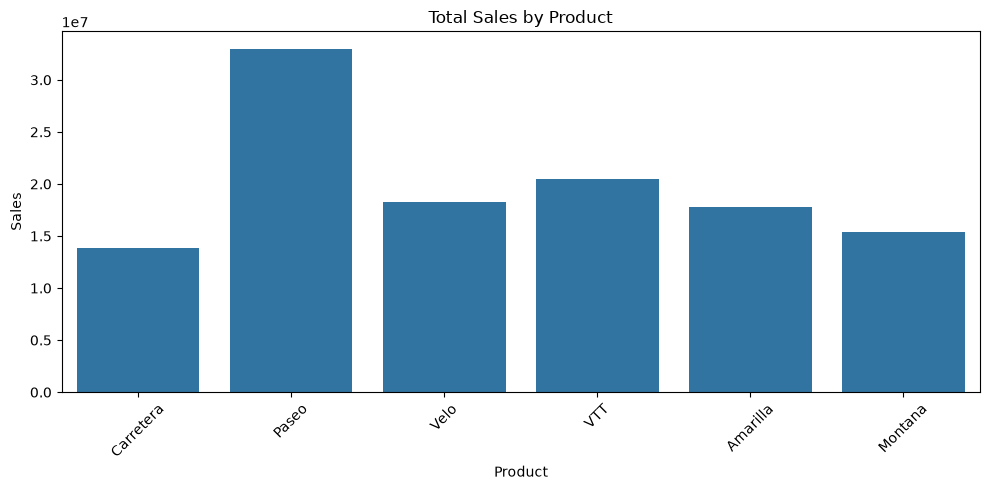

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data (Since the file is in the same folder, this will work perfectly)
df = pd.read_excel('Sample data.xlsx', sheet_name='Sheet1')

# Strip leading/trailing spaces from columns
df.columns = df.columns.str.strip()

# 2. Inspect and Handle Missing Values
print("Missing values per column:")
print(df.isnull().sum())

# Corrected 'Discount Dand' typo to 'Discount Band'
df['Discount Band'] = df['Discount Band'].fillna('None')

# 3. Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 4. Quick Visual EDA: Sales by Product
plt.figure(figsize=(10,5))
# Corrected 'dala=df' typo to 'data=df'
sns.barplot(data=df, x='Product', y='Sales', estimator=sum, errorbar=None)
plt.title('Total Sales by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_product.png')
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Reload data fresh just in case
df_model = pd.read_excel('Sample data.xlsx', sheet_name='Sheet1')
df_model.columns = df_model.columns.str.strip()
df_model['Discount Band'] = df_model['Discount Band'].fillna('None')

# 2. Choose features and target variable (Sales)
features = ['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Sale Price']
X = df_model[features]
y = df_model['Sales']

# 3. Convert categorical text fields into numeric flags
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Initialize and train the Linear Regression Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 6. Generate Predictions on the test set
y_pred = reg_model.predict(X_test)

# 7. Evaluate Performance (Fixed for newer scikit-learn versions)
r2 = r2_score(y_test, y_pred)

try:
    # Try the modern scikit-learn approach first
    from sklearn.metrics import root_mean_squared_error
    rmse = root_mean_squared_error(y_test, y_pred)
except ImportError:
    # Fallback if your version still uses the standard math root approach
    import numpy as np
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Regression Model Evaluation Results ---")
print(f"R² Score (Accuracy): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

--- Regression Model Evaluation Results ---
R² Score (Accuracy): 0.7624
Root Mean Squared Error (RMSE): $114,707.06
